In [163]:
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

In [164]:
# Load dataset
df = pd.read_csv("C:/Users/gdani/OneDrive/Desktop/master thesis/processed_model01_dataset.csv", delimiter=";")
# Define numerical and categorical columns
numerical_cols = ['duration', 'credit_amount', 'installment_rate', 'residence_duration', 'age', 'number_of_credits', 'people_liable']
categorical_cols = ['status', 'credit_history', 'purpose', 'savings/bonds', 'employment_duration', 'personal_status_and_sex',
                    'other_debtors', 'property', 'installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols)
#this simply reorder the columns of the df making sure that 'credit_risck' and 'predicted_lable' are last
final_columns = numerical_cols + [col for col in df_encoded.columns if col not in numerical_cols + ['credit_risk', 'predicted_label']] + ['credit_risk', 'predicted_label']
df_encoded = df_encoded[final_columns]
df_encoded.columns



Index(['duration', 'credit_amount', 'installment_rate', 'residence_duration',
       'age', 'number_of_credits', 'people_liable', 'id', 'status_1.0',
       'status_2.0', 'status_3.0', 'status_4.0', 'credit_history_0.0',
       'credit_history_1.0', 'credit_history_2.0', 'credit_history_3.0',
       'credit_history_4.0', 'purpose_0.0', 'purpose_1.0', 'purpose_2.0',
       'purpose_3.0', 'purpose_4.0', 'purpose_5.0', 'purpose_6.0',
       'purpose_8.0', 'purpose_9.0', 'purpose_10.0', 'savings/bonds_1.0',
       'savings/bonds_2.0', 'savings/bonds_3.0', 'savings/bonds_4.0',
       'savings/bonds_5.0', 'employment_duration_1.0',
       'employment_duration_2.0', 'employment_duration_3.0',
       'employment_duration_4.0', 'employment_duration_5.0',
       'personal_status_and_sex_1.0', 'personal_status_and_sex_2.0',
       'personal_status_and_sex_3.0', 'personal_status_and_sex_4.0',
       'other_debtors_1.0', 'other_debtors_2.0', 'other_debtors_3.0',
       'property_1.0', 'property_2.0

In [165]:
df_encoded = df_encoded.dropna()
X = df_encoded.drop(columns=['credit_risk','id', 'predicted_label'])  # Features
y_pred = df_encoded['predicted_label']  # Model's given predictions
df_encoded.to_csv("df_encoded.csv")
X

,duration,credit_amount,installment_rate,residence_duration,age,number_of_credits,people_liable,status_1.0,status_2.0,status_3.0,...,housing_2.0,housing_3.0,job_1.0,job_2.0,job_3.0,job_4.0,telephone_1.0,telephone_2.0,foreign_worker_1.0,foreign_worker_2.0
0,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,False,True,False,...,True,False,False,False,True,False,True,False,True,False
1,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,False,False,False,...,True,False,False,True,False,False,True,False,True,False
2,24.0,2835.0,3.0,4.0,53.0,1.0,1.0,False,False,False,...,True,False,False,False,True,False,True,False,True,False
3,48.0,4308.0,3.0,4.0,24.0,1.0,1.0,True,False,False,...,False,False,False,False,True,False,True,False,True,False
4,24.0,1199.0,4.0,4.0,60.0,2.0,1.0,True,False,False,...,True,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,24.0,6579.0,4.0,2.0,29.0,1.0,1.0,True,False,False,...,False,True,False,False,False,True,False,True,True,False
296,18.0,1936.0,2.0,4.0,23.0,2.0,1.0,True,False,False,...,False,False,False,True,False,False,True,False,True,False
297,36.0,3959.0,4.0,3.0,30.0,1.0,1.0,True,False,False,...,True,False,False,False,False,True,False,True,True,False
298,30.0,3857.0,4.0,4.0,40.0,1.0,1.0,True,False,False,...,True,False,False,False,False,True,False,True,True,False


In [166]:
y_pred

0      1.0
1      0.0
2      0.0
3      1.0
4      0.0
      ... 
295    1.0
296    0.0
297    1.0
298    1.0
299    1.0
Name: predicted_label, Length: 300, dtype: float64

In [167]:
X_shap = X.copy()

In [168]:
#now let's use permutation and shap to see the feature importance in a linear regression model tained on the whole dataset

                    Feature  Importance
7                status_1.0    0.181913
0                  duration    0.100661
10               status_4.0    0.097623
35  employment_duration_5.0    0.040581
1             credit_amount    0.038036
15       credit_history_4.0    0.035751
26        savings/bonds_1.0    0.033908
43             property_1.0    0.031234
2          installment_rate    0.031173
52              housing_3.0    0.031006


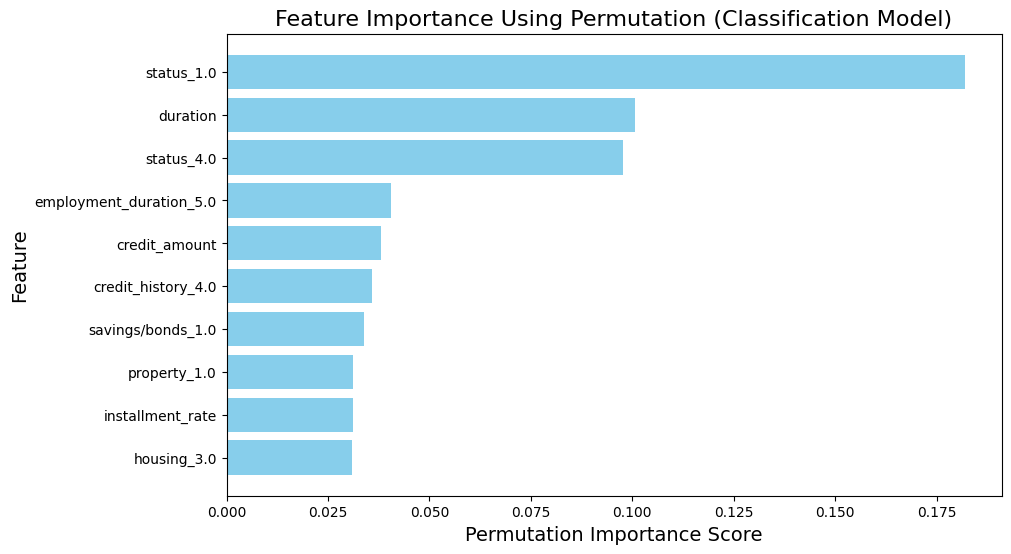

In [169]:
model = LinearRegression()
model.fit(X_shap, y_pred)

# Compute permutation importance using an appropriate regression scoring method
perm_importance = permutation_importance(
    model,  
    X_shap,
    y_pred,
    scoring="r2",  # Use R² score for regression
    n_repeats=10,  
    random_state=42
)

# Convert results into a DataFrame
importance_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

#Print Feature Importance Rankings
print(importance_df.head(10))

#Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"].head(10), importance_df["Importance"].head(10), color="skyblue")
plt.xlabel("Permutation Importance Score", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.title("Feature Importance Using Permutation (Classification Model)", fontsize=16)
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()


In [170]:
#now let's use permutation and shap to see the feature importance in linear regression models tained on groups of features

In [171]:
df2 = df_encoded.drop(columns=["id"])
#define feature groups
protected_vars = ["age"] + [col for col in df2.columns if "personal_status_and_sex" in col or "foreign_worker" in col or "job" in col]
economic_vars = ["credit_amount", "installment_rate"] + [col for col in df2.columns if "employment_duration" in col or "savings/bonds" in col]
housing_vars = ["housing_1.0", "housing_2.0", "housing_3.0", "residence_duration", "people_liable"] + [col for col in df2.columns if "property" in col]
all_features = list(set(df2.columns) - set(["credit_risk", "predicted_label"]))

In [172]:
df2

,duration,credit_amount,installment_rate,residence_duration,age,number_of_credits,people_liable,status_1.0,status_2.0,status_3.0,...,job_1.0,job_2.0,job_3.0,job_4.0,telephone_1.0,telephone_2.0,foreign_worker_1.0,foreign_worker_2.0,credit_risk,predicted_label
0,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,False,True,False,...,False,False,True,False,True,False,True,False,1.0,1.0
1,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,False,False,False,...,False,True,False,False,True,False,True,False,0.0,0.0
2,24.0,2835.0,3.0,4.0,53.0,1.0,1.0,False,False,False,...,False,False,True,False,True,False,True,False,0.0,0.0
3,48.0,4308.0,3.0,4.0,24.0,1.0,1.0,True,False,False,...,False,False,True,False,True,False,True,False,1.0,1.0
4,24.0,1199.0,4.0,4.0,60.0,2.0,1.0,True,False,False,...,False,True,False,False,True,False,True,False,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,24.0,6579.0,4.0,2.0,29.0,1.0,1.0,True,False,False,...,False,False,False,True,False,True,True,False,0.0,1.0
296,18.0,1936.0,2.0,4.0,23.0,2.0,1.0,True,False,False,...,False,True,False,False,True,False,True,False,0.0,0.0
297,36.0,3959.0,4.0,3.0,30.0,1.0,1.0,True,False,False,...,False,False,False,True,False,True,True,False,0.0,1.0
298,30.0,3857.0,4.0,4.0,40.0,1.0,1.0,True,False,False,...,False,False,False,True,False,True,True,False,0.0,1.0


In [174]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

def evaluate_feature_importance_logistic(X, y, feature_set, name):
    # Subset the features based on the feature_set
    X_subset = X[feature_set]
    
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_subset)
    
    # Train the Logistic Regression model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_scaled, y)
    
    # Create SHAP Explainer for the classification model (using predict_proba)
    explainer = shap.Explainer(model, X_scaled)
    
    # Compute SHAP values
    shap_values = explainer(X_scaled)
    
    # Plot SHAP Summary
    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, X_subset, feature_names=feature_set, show=False)
    plt.title(f"SHAP Summary Plot for {name} Feature Set", fontsize=14, pad=20)
    plt.show()  

    # Compute Permutation Importance (scoring based on accuracy for classification)
    perm_importance = permutation_importance(model, X_scaled, y, scoring='accuracy', random_state=42)
    
    # Convert the results into a DataFrame
    importance_df = pd.DataFrame({
        "Feature": feature_set,
        "Importance": perm_importance.importances_mean
    }).sort_values(by="Importance", ascending=False)
    
    # Plot Permutation Importance
    plt.figure(figsize=(10, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color="cornflowerblue")
    plt.xlabel("Permutation Importance Score (Accuracy)")
    plt.title(f"Feature Importance Using Permutation ({name})")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    
    return importance_df

# Example usage:
# importance_protected = evaluate_feature_importance_logistic(X, y, protected_vars, "Protected Variables")

In [175]:
# Prepare data
X = df2.drop(columns=["credit_risk", "predicted_label"])
y = df2["credit_risk"].astype(int)  # Ensure binary classification


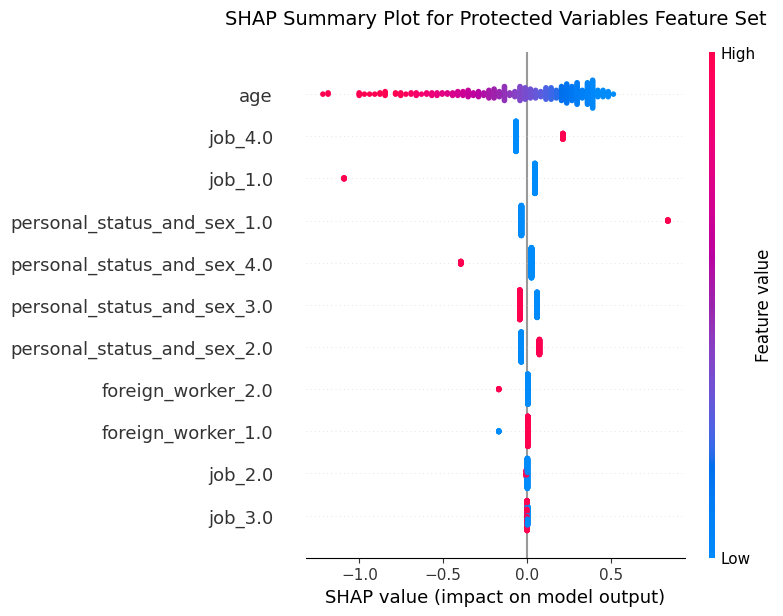

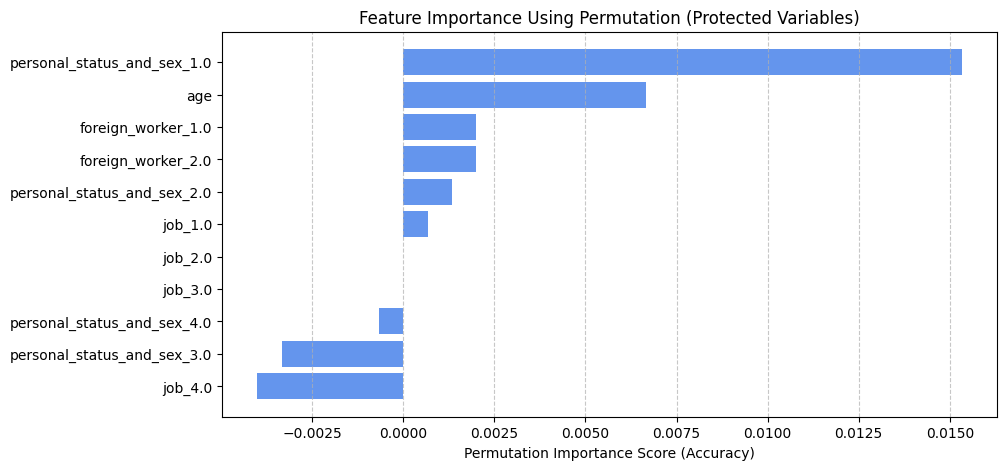

In [176]:

importance_protected = evaluate_feature_importance_logistic(X, y, protected_vars, "Protected Variables")


In [177]:
#####